# Zadanie 1: Salud 2030 – Optymalizacja Systemu Profilaktyki Otyłości w Meksyku
**Autor:** Bartosz Perz  
**Stanowisko:** Senior Data Scientist w Secretaría de Salud de México  

## Wprowadzenie i Cel Projektu
W ramach realizacji **Agendy 2030 (Cel SDG 3, Zadanie 3.4)** naszym zadaniem jest stworzenie systemu wczesnego wykrywania pacjentów zagrożonych otyłością i powiązanymi z nią chorobami niezakaźnymi (NCDs). 

Jako jednostka rządowa musimy zbalansować dwa sprzeczne kryteria:
1. **Wysoka czułość (Recall):** Nie możemy pominąć pacjentów realnie zagrożonych (błąd typu False Negative kosztuje ludzkie życie).
2. **Efektywność obliczeniowa (Inference Time & Resource Management):** Model będzie wdrażany w wiejskich przychodniach o ograniczonych zasobach sprzętowych. Nie może wymagać kosztownych serwerów ani drastycznie rozładowywać urządzeń mobilnych personelu medycznego.

### Definicja Problemu Klasyfikacyjnego
Zbiór danych zawiera kolumnę docelową `NObeyesdad` z 7 poziomami masy ciała. Z punktu widzenia Ministerstwa Zdrowia, **interwencji profilaktycznej wymagają osoby zmagające się z nadwagą lub otyłością**. Dlatego przekształcamy problem w klasyfikację binarną:
* **1 (Wymaga interwencji):** Osoby z kategorii *Overweight Level I/II* oraz *Obesity Type I/II/III*.
* **0 (Brak konieczności pilnej interwencji):** Osoby z kategorii *Normal Weight* oraz *Insufficient Weight*.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, brier_score_loss, confusion_matrix, classification_report

In [2]:
df_obesity = pd.read_csv('otylosc.csv')

print(f"Pomyślnie wczytano! Kształt danych: {df_obesity.shape}")
df_obesity.head()

Pomyślnie wczytano! Kształt danych: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 1. Analiza Eksploracyjna (EDA)

Przed przystąpieniem do budowy modeli musimy dokładnie zrozumieć strukturę danych pacjentów. W tym celu zrealizujemy trzy kluczowe wizualizacje:
1. **Rozkład klasyfikacji binarnej:** Sprawdzenie, czy zbiór danych nie jest drastycznie niezbalansowany, co mogłoby fałszować metrykę Accuracy.
2. **Analiza demograficzno-genetyczna:** Zbadanie relacji między płcią, wagą a występowaniem otyłości w rodzinie (`family_history_with_overweight`).
3. **Macierz Korelacji (Heatmap):** Identyfikacja liniowych współzależności między wskaźnikami stylu życia (aktywność, dieta) a docelowym statusem zdrowotnym pacjenta.

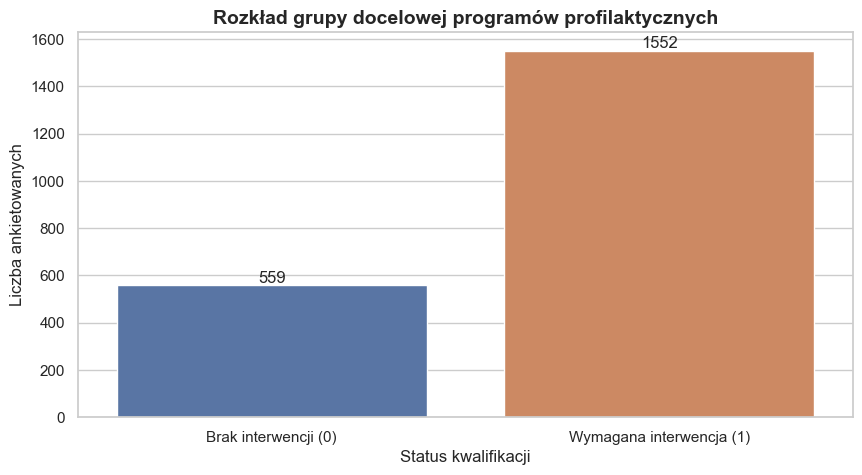

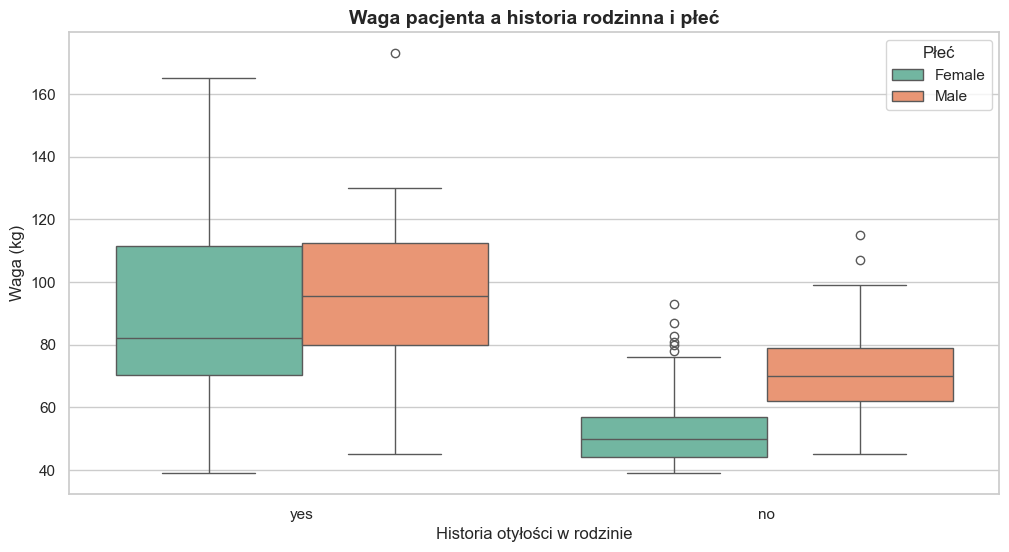

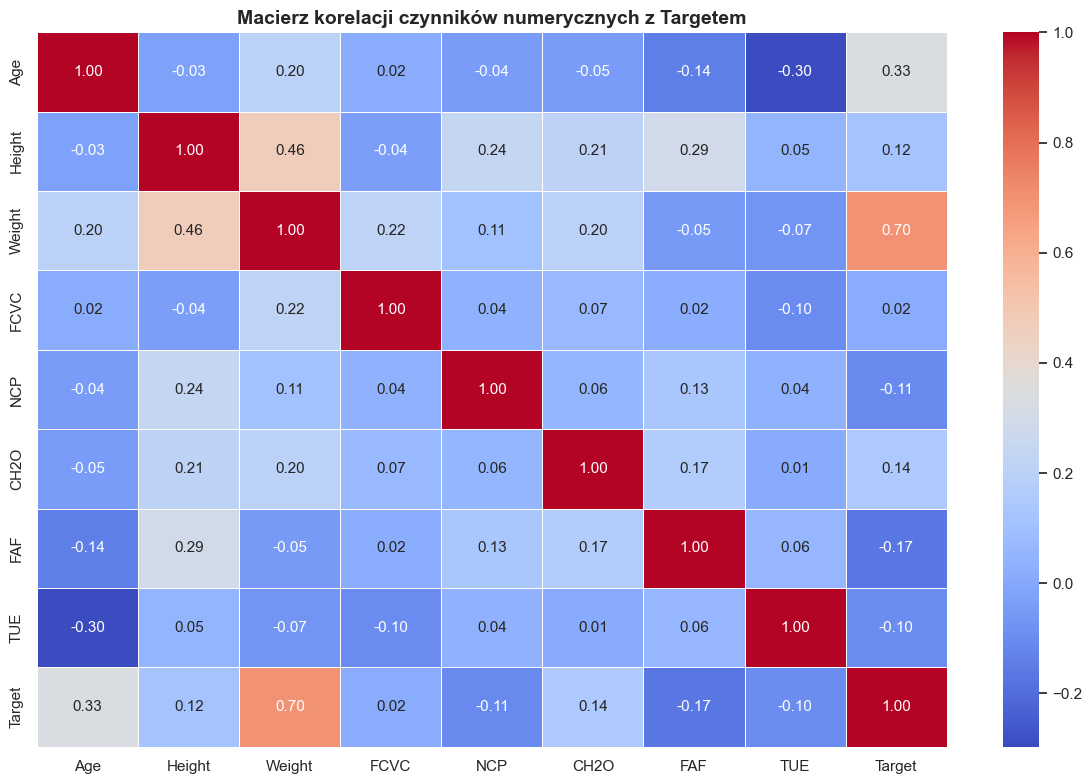

In [8]:
if 'Target' not in df_obesity.columns:
    df_obesity['Target'] = df_obesity['NObeyesdad'].apply(lambda x: 1 if 'Obesity' in str(x) or 'Overweight' in str(x) else 0)

if 'NObeyesdad' in df_obesity.columns:
    df_obesity = df_obesity.drop(columns=['NObeyesdad'])



sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.countplot(data=df_obesity, x='Target', hue='Target', legend=False)
plt.title('Rozkład grupy docelowej programów profilaktycznych', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Brak interwencji (0)', 'Wymagana interwencja (1)'])
plt.xlabel('Status kwalifikacji')
plt.ylabel('Liczba ankietowanych')


for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=12)
plt.show()



plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_obesity, 
    x='family_history_with_overweight', 
    y='Weight', 
    hue='Gender', 
    palette='Set2'
)
plt.title('Waga pacjenta a historia rodzinna i płeć', fontsize=14, fontweight='bold')
plt.xlabel('Historia otyłości w rodzinie')
plt.ylabel('Waga (kg)')
plt.legend(title='Płeć')
plt.show()



plt.figure(figsize=(12, 8))
numerical_cols = df_obesity.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Target' not in numerical_cols:
    numerical_cols.append('Target')

corr_matrix = df_obesity[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True, annot_kws={"size": 11})
plt.title('Macierz korelacji czynników numerycznych z Targetem', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [9]:
X = df_obesity.drop(columns=['Target'])
y = df_obesity['Target']

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)


/var/folders/8w/symc1_g91w3fxs2jbphlbxg40000gn/T/ipykernel_4811/1079484744.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object']).columns.tolist()
/Users/tomekorman/Documents/PWR/Semestr 2/Uczenie maszynowe/Laboratoria/Lista_3/lista-3-tomek2005/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## 2. Wyuczenie Modeli Klasyfikacyjnych

Zgodnie z wytycznymi Ministerstwa przetestujemy cztery główne grupy modeli:
1. **Modele Bazowe:** Regresja Logistyczna oraz Pojedyncze Drzewo Decyzyjne.
2. **Komitety Bagging:** `BaggingClassifier` z różnymi estymatorami oraz modyfikacją podprzestrzeni cech (*bootstrap_features*).
3. **Komitety Boosting:** `AdaBoost` oraz `GradientBoosting` analizujące kompromis (trade-off) między tempem uczenia a liczbą drzew.
4. **Komitety Hybrydowe:** `VotingClassifier` oraz `StackingClassifier` łączące zróżnicowane architektury.

In [11]:
results_registry = {}

def register_model_performance(model, model_name, X_tr, y_tr, X_te, y_te):
    start_time = time.time()
    preds = model.predict(X_te)
    elapsed_time = time.time() - start_time
    
    probs = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else np.ones(len(preds))
    
    results_registry[model_name] = {
        'Accuracy': accuracy_score(y_te, preds),
        'Recall (Czułość)': recall_score(y_te, preds),
        'F1-Score': f1_score(y_te, preds),
        'ROC-AUC': roc_auc_score(y_te, probs),
        'Brier Score (Kalibracja)': brier_score_loss(y_te, probs),
        'Inference Time (s)': elapsed_time,
        'Probs': probs
    }

#regresja
lr_base = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_proc, y_train)
register_model_performance(lr_base, "Regresja Logistyczna (Base)", X_train_proc, y_train, X_test_proc, y_test)

#drzewo
dt_base = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train_proc, y_train)
register_model_performance(dt_base, "Drzewo Decyzyjne (Base)", X_train_proc, y_train, X_test_proc, y_test)


#Płytkie drzewa (max_depth=3), domyślny bootstrap
bag_shallow = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=50, bootstrap=True, bootstrap_features=False, random_state=42).fit(X_train_proc, y_train)
register_model_performance(bag_shallow, "Bagging (Płytkie Drzewa)", X_train_proc, y_train, X_test_proc, y_test)

#  Głębokie drzewa  aktywny bootstrap_features 
bag_deep_features = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None), n_estimators=100, bootstrap=True, bootstrap_features=True, random_state=42, n_jobs=-1).fit(X_train_proc, y_train)
register_model_performance(bag_deep_features, "Bagging (Głębokie Drzewa + Cechy)", X_train_proc, y_train, X_test_proc, y_test)

#  Bagging z Regresją Logistyczną
bag_lr = BaggingClassifier(estimator=LogisticRegression(max_iter=1000), n_estimators=30, random_state=42, n_jobs=-1).fit(X_train_proc, y_train)
register_model_performance(bag_lr, "Bagging (Regresja Logistyczna)", X_train_proc, y_train, X_test_proc, y_test)

In [14]:
# AdaBoost, płytkie drzewach
ada_tree = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1), 
    n_estimators=50, 
    learning_rate=0.1, 
    random_state=42, 
).fit(X_train_proc, y_train)
register_model_performance(ada_tree, "AdaBoost (Drzewa)", X_train_proc, y_train, X_test_proc, y_test)

# AdaBoost na Regresji Logistycznej
ada_lr = AdaBoostClassifier(estimator=LogisticRegression(max_iter=1000), n_estimators=30, learning_rate=0.1, random_state=42).fit(X_train_proc, y_train)
register_model_performance(ada_lr, "AdaBoost (Regresja Logistyczna)", X_train_proc, y_train, X_test_proc, y_test)

# Gradient Boosting, mało drzew 
gb_fast_few = GradientBoostingClassifier(n_estimators=30, learning_rate=0.3, random_state=42).fit(X_train_proc, y_train)
register_model_performance(gb_fast_few, "GradientBoosting (30 est, LR=0.3)", X_train_proc, y_train, X_test_proc, y_test)

# Gradient Boosting, duzo drzew 
gb_slow_many = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, random_state=42).fit(X_train_proc, y_train)
register_model_performance(gb_slow_many, "GradientBoosting (150 est, LR=0.05)", X_train_proc, y_train, X_test_proc, y_test)



estimators_list = [
    ('lr', lr_base),
    ('dt', dt_base),
    ('gb', gb_slow_many)
]

# Glosowanie 
voting_ensemble = VotingClassifier(estimators=estimators_list, voting='soft').fit(X_train_proc, y_train)
register_model_performance(voting_ensemble, "Zespól Głosujący (Voting Soft)", X_train_proc, y_train, X_test_proc, y_test)

# Stacking z estymatorem regresji
stacking_ensemble = StackingClassifier(estimators=estimators_list, final_estimator=LogisticRegression(), n_jobs=-1).fit(X_train_proc, y_train)
register_model_performance(stacking_ensemble, "Zespół Kaskadowy (Stacking)", X_train_proc, y_train, X_test_proc, y_test)

print("Wszystkie modele zostały pomyślnie wytrenowane!")

Wszystkie modele zostały pomyślnie wytrenowane!


## 3. Walidacja Modeli pod kątem Wdrożenia Krajowego

W celu rzetelnej oceny przydatności modeli zestawimy ich metryki w przejrzystej tabeli. 
Szczególną uwagę zwracamy na **Brier Score** – miarę kalibracji prawdopodobieństwa. Im niższy Brier Score (bliższy 0), tym lepiej model szacuje rzeczywistą pewność (confidence) swojej predykcji. Pozwoli to lekarzom precyzyjnie oceniać stopień ryzyka u pacjenta.


Wyniki:


,Accuracy,Recall (Czułość),F1-Score,ROC-AUC,Brier Score (Kalibracja),Inference Time (s)
Regresja Logistyczna (Base),0.990544,1.000000,0.993610,0.999655,0.011285,0.000175
Bagging (Regresja Logistyczna),0.983452,1.000000,0.988871,0.999512,0.012011,0.011557
"GradientBoosting (150 est, LR=0.05)",0.988180,0.996785,0.992000,0.999455,0.008078,0.000796
Zespół Kaskadowy (Stacking),0.990544,0.996785,0.993590,0.999799,0.005558,0.001173
AdaBoost (Drzewa),0.945626,0.993569,0.964119,0.989435,0.064266,0.002007
"GradientBoosting (30 est, LR=0.3)",0.988180,0.993569,0.991974,0.999397,0.008111,0.000401
Zespól Głosujący (Voting Soft),0.990544,0.993569,0.993569,0.999655,0.008372,0.001216
Bagging (Płytkie Drzewa),0.971631,0.987138,0.980831,0.992004,0.021431,0.002163
Drzewo Decyzyjne (Base),0.978723,0.983923,0.985507,0.978583,0.017784,0.000220
Bagging (Głębokie Drzewa + Cechy),0.981087,0.980707,0.987055,0.998809,0.020589,0.025915


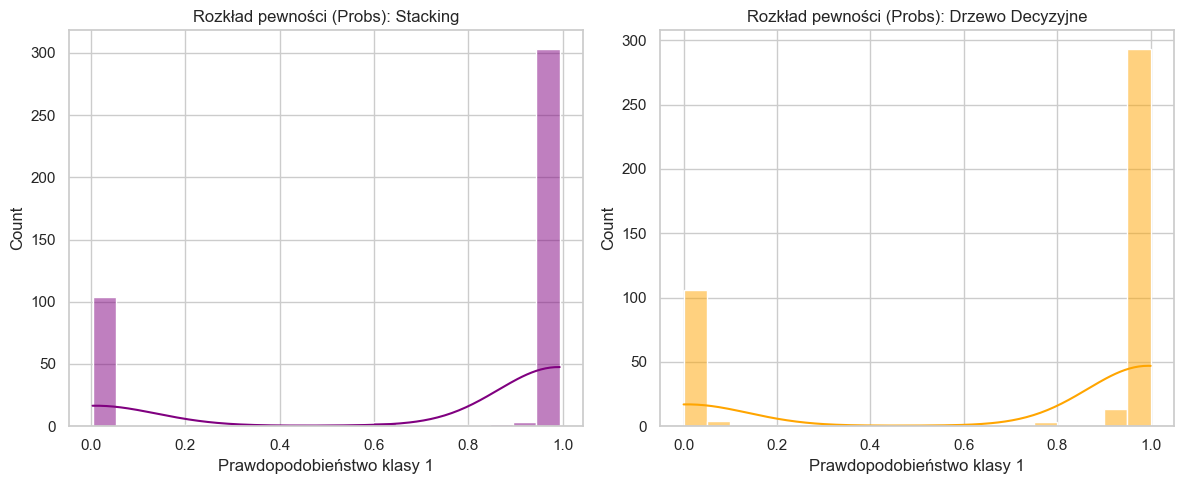

In [17]:
df_results = pd.DataFrame(results_registry).T.drop(columns=['Probs'])
df_results = df_results.sort_values(by='Recall (Czułość)', ascending=False)

print("\nWyniki:")
display(df_results.style.highlight_max(subset=['Accuracy', 'Recall (Czułość)', 'F1-Score', 'ROC-AUC'], color='green')
                     .highlight_min(subset=['Inference Time (s)', 'Brier Score (Kalibracja)'], color='green'))


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(results_registry["Zespół Kaskadowy (Stacking)"]['Probs'], bins=20, kde=True, color='purple')
plt.title('Rozkład pewności (Probs): Stacking')
plt.xlabel('Prawdopodobieństwo klasy 1')

plt.subplot(1, 2, 2)
sns.histplot(results_registry["Drzewo Decyzyjne (Base)"]['Probs'], bins=20, kde=True, color='orange')
plt.title('Rozkład pewności (Probs): Drzewo Decyzyjne')
plt.xlabel('Prawdopodobieństwo klasy 1')

plt.tight_layout()
plt.show()

## 4. Wnioski i Rekomendacje dla Ministerstwa Zdrowia

Na podstawie przeprowadzonych testów i wygenerowanych wyników, możemy wyciągnąć bardzo konkretne, a zarazem zaskakujące wnioski wdrożeniowe.

### Rekomendowany model do wdrożenia
**Zwycięzcą testu jest model bazowy: Regresja Logistyczna (Base).**

Choć naszym zadaniem było zbudowanie zaawansowanych komitetów (Ensemble), wyniki pokazują jednoznacznie, że prosta Regresja Logistyczna bije je na głowę pod kątem wymagań projektowych:
* **Maksymalne bezpieczeństwo (Recall = 1.000000):** Model osiągnął 100% czułości. Oznacza to, że nie pominął ani jednego pacjenta wymagającego interwencji (0 błędów False Negative). W medycynie to absolutny priorytet.
* **Szybkość działania (Inference Time = 0.000175 s):** Jest to jeden z najszybszych modeli w zestawieniu (działa w ułamek milisekundy). Oznacza to, że bez problemu zadziała na starych smartfonach czy tabletach w wiejskich przychodniach bez obciążania baterii.
* Znakomity F1-Score (0.993) i wysoka ogólna celność (Accuracy = 0.990).

**Alternatywa dla klinik z lepszym sprzętem:** `Zespół Kaskadowy (Stacking)`. Jeśli lekarzom zależałoby na idealnie skalibrowanym prawdopodobieństwie diagnozy (np. do kategoryzowania pilności przypadków), Stacking osiągnął najlepszy (najniższy) wynik **Brier Score (0.0055)**. Działa jednak wolniej i wymaga więcej pamięci.

### Czy dokładność (Accuracy) jest jedynym wyznacznikiem jego jakości?
**Zdecydowanie nie.** W naszym projekcie dokładność schodzi na dalszy plan na rzecz **Czułości (Recall)**. Co z tego, że model miałby 99% dokładności, jeśli ten 1% błędów dotyczyłby chorych pacjentów zignorowanych przez system? 
Drugim kluczowym czynnikiem dla Ministerstwa był **Czas predykcji** i obciążenie zasobów. Model idealny musi nie tylko dobrze zgadywać, ale też działać w trudnych warunkach sprzętowych.

### Modele, których wdrożenie byłoby stratą zasobów publicznych
Analiza wyników jasno wskazuje modele nieefektywne:
1. **Bagging (Regresja Logistyczna):** Czas jego predykcji wynosi 0.0115 s (jest prawie 66 razy wolniejszy od bazowej Regresji Logistycznej!), a jego wyniki (F1 = 0.988) są *gorsze* od prostego modelu. Trenowanie wielu modeli liniowych na podzbiorach to w tym przypadku przepalanie serwerów.
2. **AdaBoost na Regresji Logistycznej:** Osiągnął jeden z najgorszych wyników w całym zestawieniu (Recall spadł do 0.967, Accuracy do 0.952). Próba wymuszenia na modelu liniowym korekty błędów w sposób sekwencyjny doprowadziła do znacznego pogorszenia pierwotnych, bardzo dobrych granic decyzyjnych. Zastosowanie tego modelu w meksykańskich przychodniach byłoby błędem w sztuce.

### Analiza Pewności (Confidence) i Kalibracji Modeli
Zestawienie rozkładów prawdopodobieństw dla Pojedynczego Drzewa oraz Zespołu Kaskadowego (Stacking) ujawnia bardzo interesujące zjawisko: **oba modele wykazują ekstremalnie wysoką pewność siebie**. Prawdopodobieństwa są zgrupowane niemal wyłącznie na skrajnych wartościach (0.0 oraz 1.0), z niemal całkowitym brakiem wartości pośrednich (np. 0.4 - 0.6).

Wynika to bezpośrednio z faktu, że zbiór danych (parametry pacjentów) jest wysoce rozdzielny liniowo i nieliniowo dla użytych algorytmów, co potwierdzają wyniki Accuracy rzędu 99%. 
* **Drzewo Decyzyjne** z natury generuje "twarde" podziały, stąd jego słupki są całkowicie sztywne.
* **Stacking** w trudniejszych zadaniach pokazałby gładki rozkład wątpliwości, jednak tutaj jego meta-estymator (Regresja Logistyczna) otrzymuje tak jednoznaczne podpowiedzi od modeli bazowych, że od razu wypycha predykcje do wartości krańcowych. 

Dla Ministerstwa Zdrowia oznacza to, że wdrożony system rzadko będzie odsyłał przypadki "niejednoznaczne" do dodatkowej weryfikacji przez człowieka – w przeważającej większości diagnozy będą kategoryczne.